# 01 Exercise: Bank Marketing Conversion Prediction

In this exercise, you apply the same supervised learning workflow to a new business problem.

The dataset contains results from direct marketing campaigns of a Portuguese banking institution. The business goal is to predict whether a customer will subscribe to a term deposit after being contacted.

This is a realistic campaign-prioritization problem: the model should help decide which customers are most promising for a future campaign.


## Learning Goals

By the end of this exercise, you should be able to:

- formulate a business-oriented prediction problem,
- explore target distribution and segment-level conversion rates,
- identify potential leakage features,
- build a preprocessing and modeling pipeline,
- compare a simple and a more complex model,
- evaluate the model with classification metrics and a simple business KPI,
- inspect errors across customer segments.


## Dataset

Source: UCI Machine Learning Repository, Bank Marketing Dataset  
URL: https://archive.ics.uci.edu/dataset/222/bank+marketing

We use `bank-full.csv`, which contains 45,211 observations and 17 columns.

Target variable:

- `y`: whether the customer subscribed to a term deposit (`yes` / `no`)

Important note:

- `duration` describes the duration of the last contact call. This value is only known after a customer has already been contacted. If the goal is to prioritize customers before calling them, `duration` is not available at prediction time and should usually be excluded from the model.


## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
            

In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "bank_marketing" / "bank-full.csv").exists():
            return path
    raise FileNotFoundError("Could not find bank-full.csv in data/raw/bank_marketing.")
                

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank_marketing" / "bank-full.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
                

Project root: /home/patri/master/ads2-bank-marketing-project
Data path: /home/patri/master/ads2-bank-marketing-project/data/raw/bank_marketing/bank-full.csv


## 2. Load Data

In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

print(df.shape)
df.head()


(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


- There are no missing values
- Duration - leakage?
last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  -> source IC data source page. could lead to data leakage where the model knows information about the duration of the call even before the call is made. 
Variable should not be addeed to the train split.

## 3. Data Story

Write a short data story in your own words.

Guiding questions:

- What business decision should this model support?
    The model should help the bank decide which customers should be contacted first in a marketing campaign to increase the probability of a term deposit subscription.
- Who would use the prediction?
    The marketing team and campaign managers would use the predictions to decide which customers to contact.
- What action could be triggered by a high predicted conversion probability?
    The customers that have a high probability of conversion should be prioritized and be contacted first during the next marketing campaign.
- What are possible costs of false positives and false negatives?
    False positive: so when the model predicts "yes" this person will probably subscribe to a term deposit but they dont in the end meaning extra calls have been done without conversion, the client didnt accept the offer.
    False negative: the model predicts "no" this person will probably not subscribe so the marketing team decides not to call and end up losing a client that would have suscribed if they would have gotten a call.


In [5]:
# Your notes:
# - Business decision:
# - Users:
# - Possible action:
# - Cost of false positives:
# - Cost of false negatives:


## 4. Data Exploration

#### Key questions
- Is the target variable imbalanced?
- Which variables appear important?
- Which variables require cleaning?
- Which variables may require feature engineering?
- Are there interesting patterns?
- Are there suspicious correlations?
- Could there be potential Data Leakage?

In [6]:
target_rate = df["y"].value_counts(normalize=True).rename("share")
target_rate

y
no     0.883015
yes    0.116985
Name: share, dtype: float64

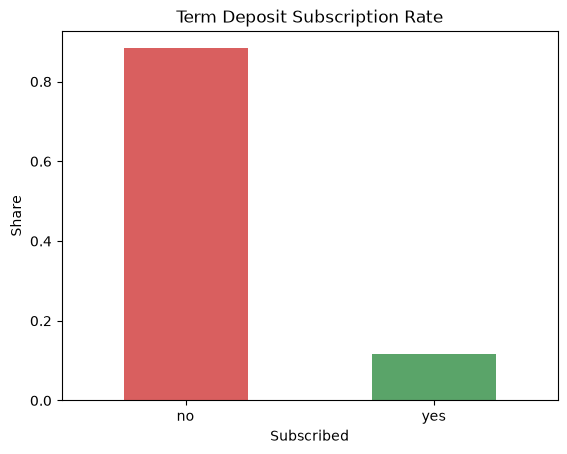

In [7]:
ax = target_rate.sort_index().plot(kind="bar", color=["#d95f5f", "#5aa469"])
ax.set_title("Term Deposit Subscription Rate")
ax.set_xlabel("Subscribed")
ax.set_ylabel("Share")
plt.xticks(rotation=0)
plt.show()


yes = 12%  
no = 88%   
Dataset is unbalanced

### Exercise 1: Segment-Level Conversion Rates

Inspect conversion rates by relevant customer and campaign attributes.

Suggested variables:

- `job`
- `education`
- `housing`
- `loan`
- `contact`
- `month`
- `poutcome`

Questions:

- Which segments have high conversion rates?
- Which segments have low conversion rates?
- Are there small groups that should be interpreted carefully?


In [8]:
def conversion_by_group(data: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        data.groupby(column)
        .agg(
            n=("y", "size"),
            conversion_rate=("y", lambda s: s.eq("yes").mean()),
        )
        .sort_values("conversion_rate", ascending=False)
    )


# Try different columns here.
conversion_by_group(df, "poutcome")


,n,conversion_rate
poutcome,,
success,1511,0.647253
other,1840,0.166848
failure,4901,0.126097
unknown,36959,0.091615


In [9]:
# TODO: Create one or two additional plots for segment-level conversion rates.
# Hint: Start with conversion_by_group(df, "job") or conversion_by_group(df, "month").
job_conversion = conversion_by_group(df, "job")
job_conversion


,n,conversion_rate
job,,
student,938,0.286780
retired,2264,0.227915
unemployed,1303,0.155027
management,9458,0.137556
admin.,5171,0.122027
self-employed,1579,0.118429
unknown,288,0.118056
technician,7597,0.110570
services,4154,0.088830


In [10]:
df["job"].value_counts()


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

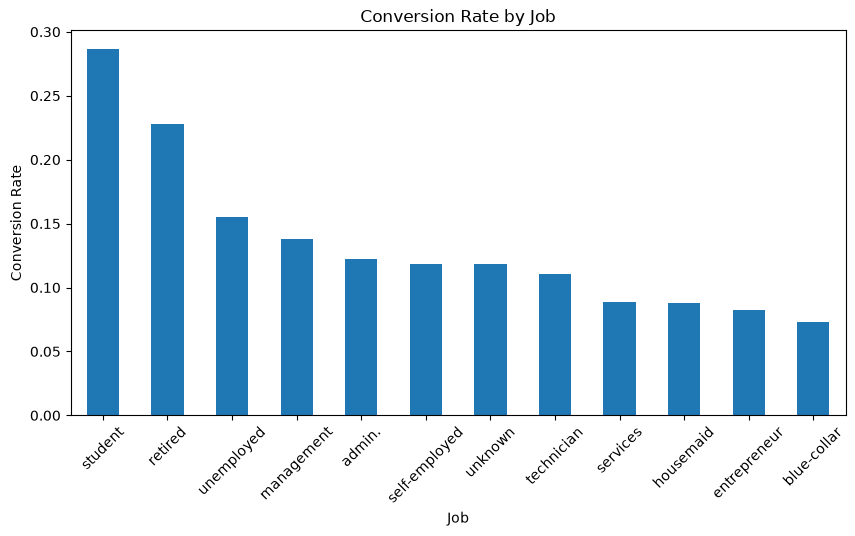

In [11]:
job_conversion["conversion_rate"].plot(
    kind="bar",
    figsize=(10,5),
    title="Conversion Rate by Job"
)

plt.ylabel("Conversion Rate")
plt.xlabel("Job")
plt.xticks(rotation=45)

plt.show()

if the call is made, the people that will subscribe to the term subscription the most are students followed by retired and unemployed people.
Blue-collar customer show the lowest.
However students form a relatively small group so the result should be interpreted carefully.

In [12]:
month_conversion = conversion_by_group(df, "month")
month_conversion

,n,conversion_rate
month,,
mar,477,0.519916
dec,214,0.467290
sep,579,0.464594
oct,738,0.437669
apr,2932,0.196794
feb,2649,0.166478
aug,6247,0.110133
jun,5341,0.102228
nov,3970,0.101511


In [13]:
df["month"].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

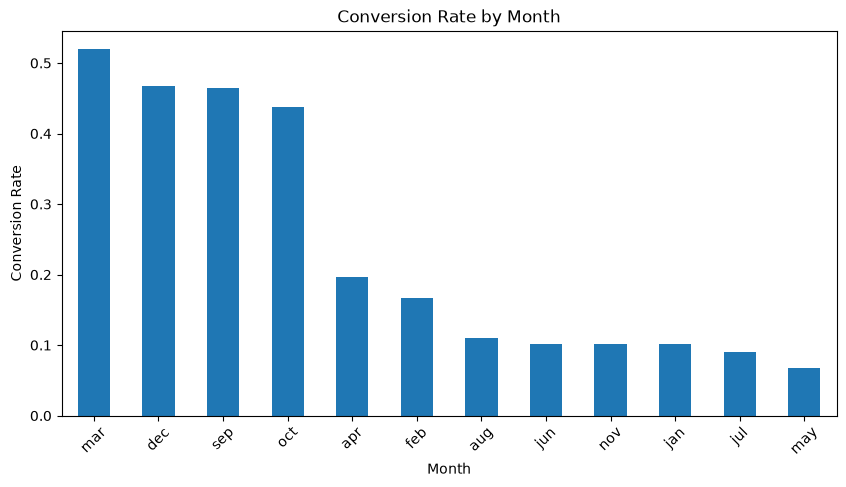

In [14]:
month_conversion["conversion_rate"].plot(
    kind="bar",
    figsize=(10,5),
    title="Conversion Rate by Month"
)

plt.ylabel("Conversion Rate")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.show()

Customers contacted in March show the highest conversion rate, followed by December, September and October.

This may indicate seasonal effects or differences in marketing campaigns. Cant draw conclussions yet.

Same happens with the months here. 

In [15]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows in the dataset.

## 5. Feature Review and Leakage Check

Before modeling, decide which features are realistically available at prediction time.

Important discussion point:

- `duration` is strongly related to the outcome, but it is only known after the call has happened. If the model is used to decide whom to call, this feature leaks future information into training.

Exercise:

- Train the main model without `duration`.
- Optionally compare it to a model with `duration` and explain why that performance is not realistic for pre-campaign scoring.


In [16]:
target_column = "y"
leakage_columns = ["duration"]
identifier_columns = []

feature_columns = [
    column
    for column in df.columns
    if column not in [target_column, *leakage_columns, *identifier_columns]
]

X = df[feature_columns].copy()
y = df[target_column].eq("yes").astype(int)

print(f"Number of features used: {len(feature_columns)}")
print(feature_columns)


Number of features used: 15
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


## 6. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.mean().round(4), y_test.mean().round(4))


(36168, 15) (9043, 15)
0.117 0.117


## 7. Preprocessing Pipeline

In [18]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 8. Evaluation Function

Complete or adapt the evaluation function if needed.

Think about which metric should matter most for a marketing campaign:

- High precision means fewer wasted calls.
- High recall means fewer missed potential subscribers.
- F1 balances both.
- ROC-AUC evaluates ranking quality across thresholds.


In [19]:
def evaluate_classifier(model: Pipeline, model_name: str) -> dict:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    print(model_name)
    print(classification_report(y_test, y_pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(model_name)
    plt.show()

    return metrics


## 9. Baseline Model: Logistic Regression

In [20]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

# TODO: Fit and evaluate the logistic regression model.
# logistic_model.fit(X_train, y_train)
# logistic_result = evaluate_classifier(logistic_model, "Logistic Regression")
# logistic_result


## 10. More Complex Model: XGBoost

In [21]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                min_child_weight=5,
                subsample=0.9,
                colsample_bytree=0.9,
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# TODO: Fit and evaluate the XGBoost model.
# xgboost_model.fit(X_train, y_train)
# xgboost_result = evaluate_classifier(xgboost_model, "XGBoost")
# xgboost_result


## 11. Model Comparison

Compare the two models.

Questions:

- Which model has better recall?
- Which model has better precision?
- Which model would you choose for a campaign with limited contact capacity?
- Which model would you choose if missing potential subscribers is very costly?


In [22]:
# TODO: Build a comparison dataframe after fitting both models.
# comparison_df = pd.DataFrame([logistic_result, xgboost_result])
# comparison_df.sort_values("f1", ascending=False)


## 12. Simple Business KPI

Define a simplified campaign KPI.

Example assumptions:

- Contacting one customer costs 2 EUR.
- A successful term-deposit conversion creates 80 EUR business value.
- The campaign contacts all customers whose predicted probability is above a chosen threshold.

Exercise:

- Calculate expected campaign value for different thresholds.
- Compare model metrics with business value.
- Explain why the best model metric does not automatically imply the best campaign strategy.


In [23]:
def campaign_value_at_threshold(
    model: Pipeline,
    threshold: float,
    contact_cost: float = 2.0,
    conversion_value: float = 80.0,
) -> dict:
    y_proba = model.predict_proba(X_test)[:, 1]
    contacted = y_proba >= threshold

    realized_conversions = int((contacted & y_test.eq(1)).sum())
    number_contacted = int(contacted.sum())
    total_value = realized_conversions * conversion_value - number_contacted * contact_cost

    return {
        "threshold": threshold,
        "number_contacted": number_contacted,
        "realized_conversions": realized_conversions,
        "total_value": total_value,
        "value_per_contact": total_value / number_contacted if number_contacted else 0,
    }


# TODO: Evaluate campaign value across thresholds for your selected model.
# thresholds = np.arange(0.05, 0.95, 0.05)
# business_results = pd.DataFrame([
#     campaign_value_at_threshold(xgboost_model, threshold)
#     for threshold in thresholds
# ])
# business_results.sort_values("total_value", ascending=False).head()


## 13. Error Slicing

Inspect whether model performance differs across customer groups.

Suggested slices:

- `job`
- `education`
- `housing`
- `loan`
- `contact`
- `poutcome`

Questions:

- Are some segments difficult because conversion is rare?
- Are some segments selected often but with low precision?
- Which segment would you inspect first before using the model operationally?


In [24]:
# TODO: Create prediction results for the selected model and calculate slice-level metrics.
# selected_model = xgboost_model
# y_pred = selected_model.predict(X_test)
# y_proba = selected_model.predict_proba(X_test)[:, 1]
#
# predictions = X_test.copy()
# predictions["y_true"] = y_test
# predictions["y_pred"] = y_pred
# predictions["conversion_probability"] = y_proba
#
# def slice_metrics(data: pd.DataFrame, column: str) -> pd.DataFrame:
#     rows = []
#     for value, group in data.groupby(column, dropna=False):
#         rows.append({
#             "slice_column": column,
#             "slice_value": value,
#             "n": len(group),
#             "conversion_rate": group["y_true"].mean(),
#             "precision": precision_score(group["y_true"], group["y_pred"], zero_division=0),
#             "recall": recall_score(group["y_true"], group["y_pred"], zero_division=0),
#             "f1": f1_score(group["y_true"], group["y_pred"], zero_division=0),
#         })
#     return pd.DataFrame(rows)
#
# slice_metrics(predictions, "job").sort_values("recall")


## 14. Reflection

Write a short reflection.

Questions:

- Which model would you recommend and why?
- Which metric was most useful for this business case?
- Did the business KPI change your view of the model comparison?
- Which feature or data quality issue would you discuss with the business team?
- What would need to be monitored if this model was used in production?


In [25]:
# Your reflection:
# - Recommended model:
# - Most useful metric:
# - Business KPI insight:
# - Business/data question:
# - Production monitoring idea:
